In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.metrics import classification_report
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

## 1. Load Dataset (Credit Card Fraud Detection Dataset)

In [2]:
# Download from Kaggle

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
path

100%|██████████████████████████████████████| 66.0M/66.0M [00:16<00:00, 4.18MB/s]

Extracting files...


'/home/asus/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3'

In [6]:
os.listdir(path)

['creditcard.csv']

In [7]:
df = pd.read_csv(f"{path}/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Because of privacy, original features names cannot be provided, and V1, V2, ... V28 are obtained from PCA.

In [8]:
df.shape

(284807, 31)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [13]:
# Is the dataset balanced?

df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

* There are no missing values.
* The dataset is highly unbalanced (fraud cases are rare). However, these labels won't be used during the training

In [14]:
# Drop target

X = df.drop("Class", axis=1)
y = df["Class"]

## 2. EDA

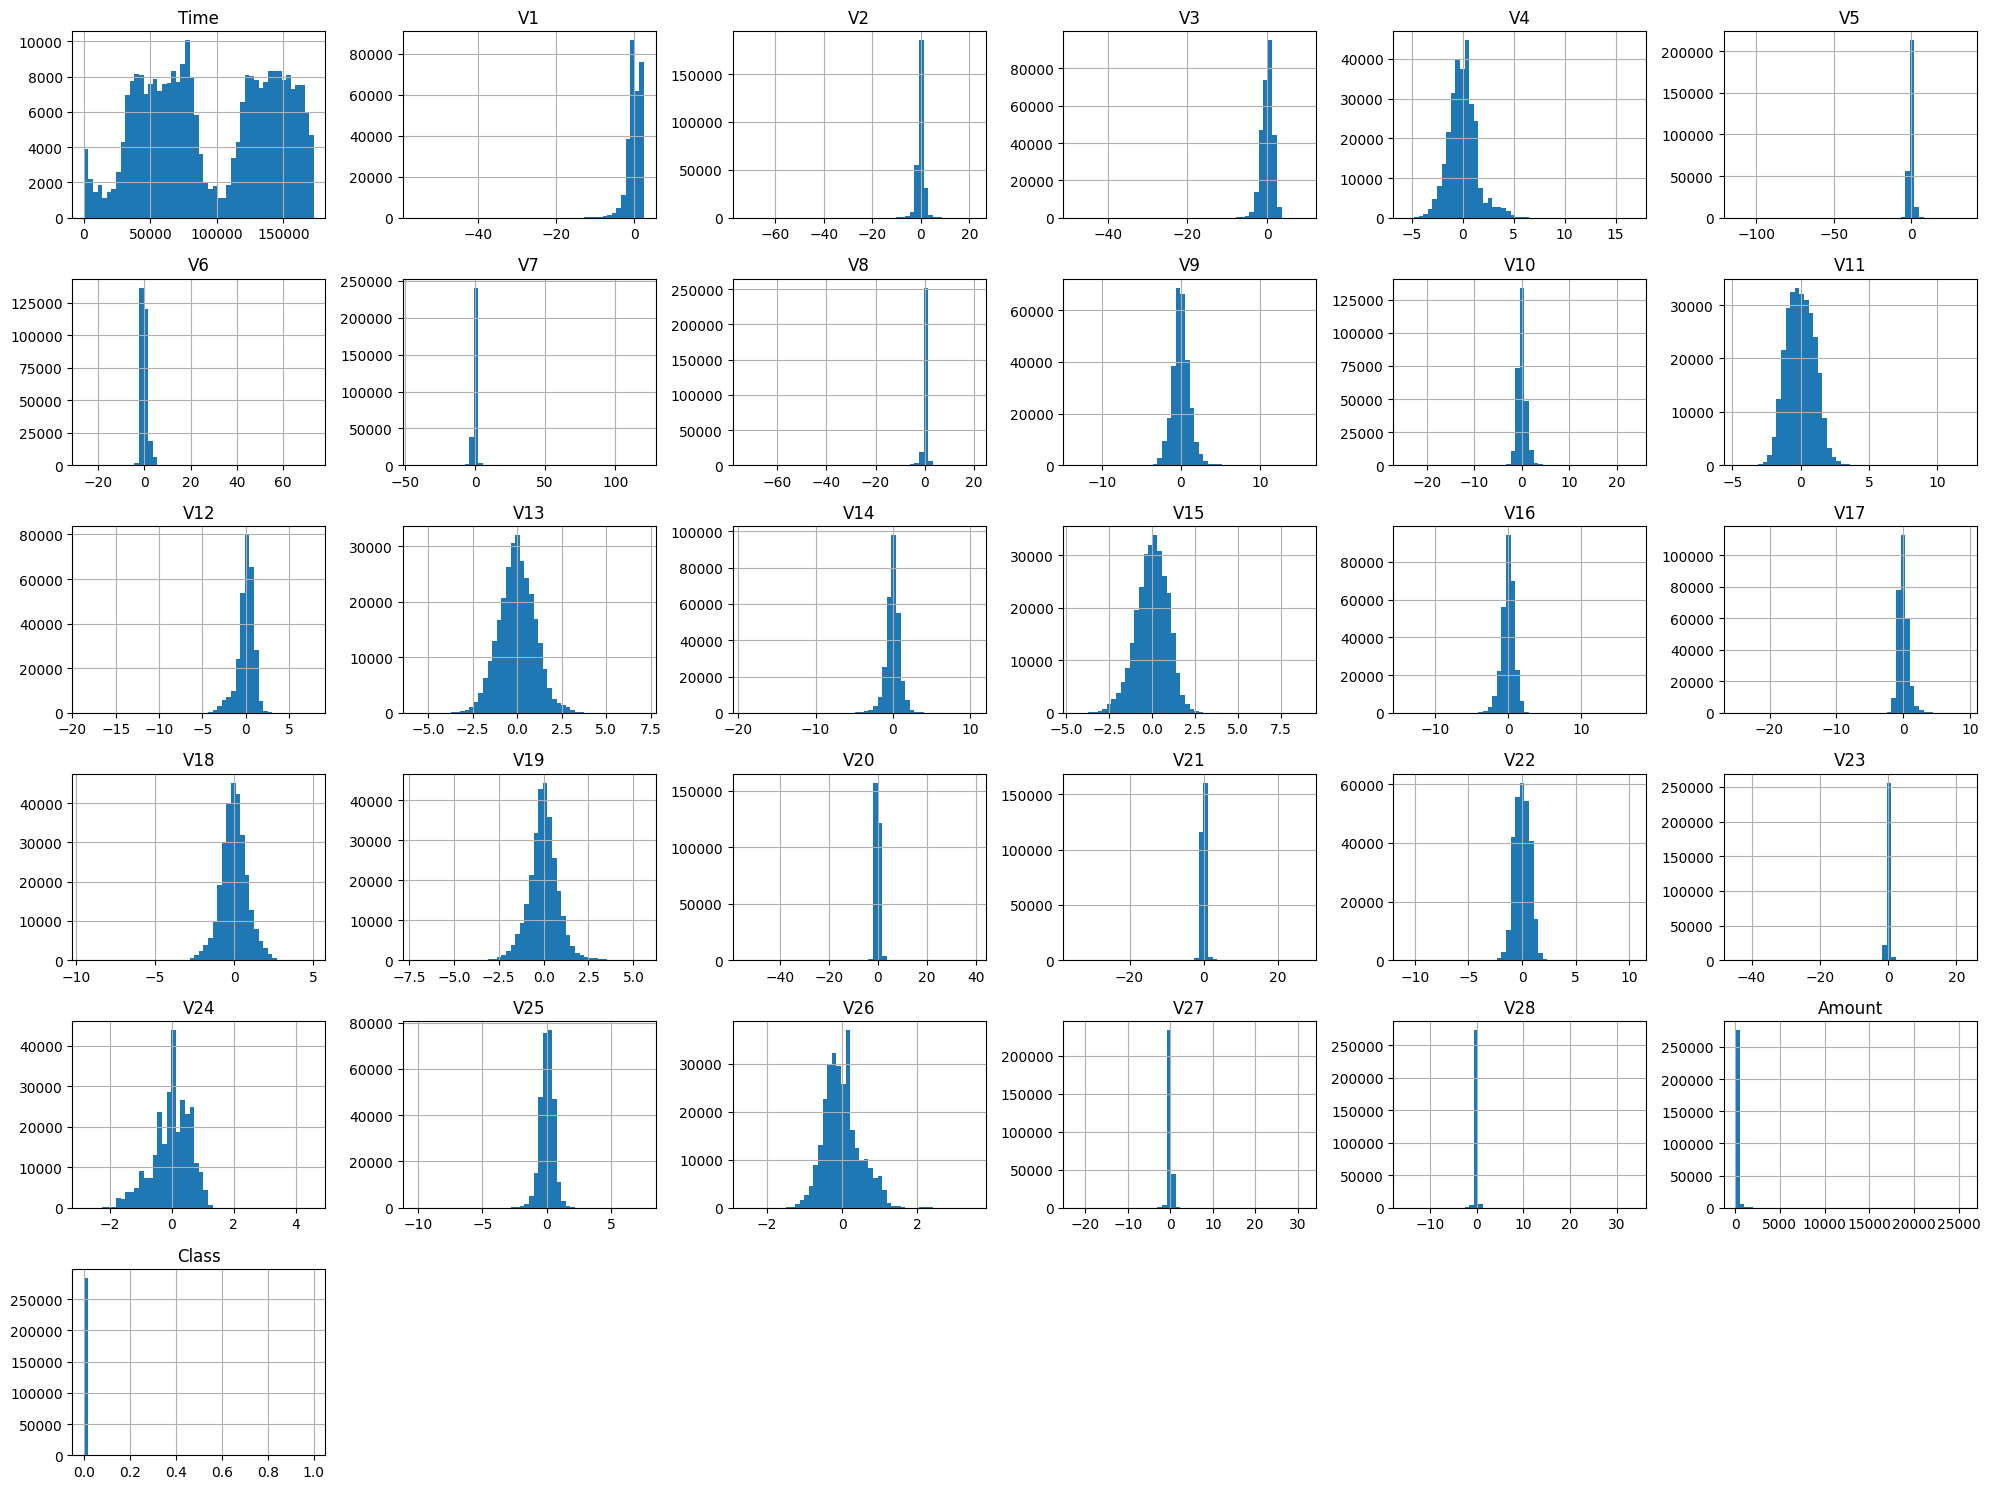

In [15]:
df.hist(figsize=(20,15), bins=50)
plt.tight_layout()
plt.show()

* Some features are skewed
* Other features show more extreme values

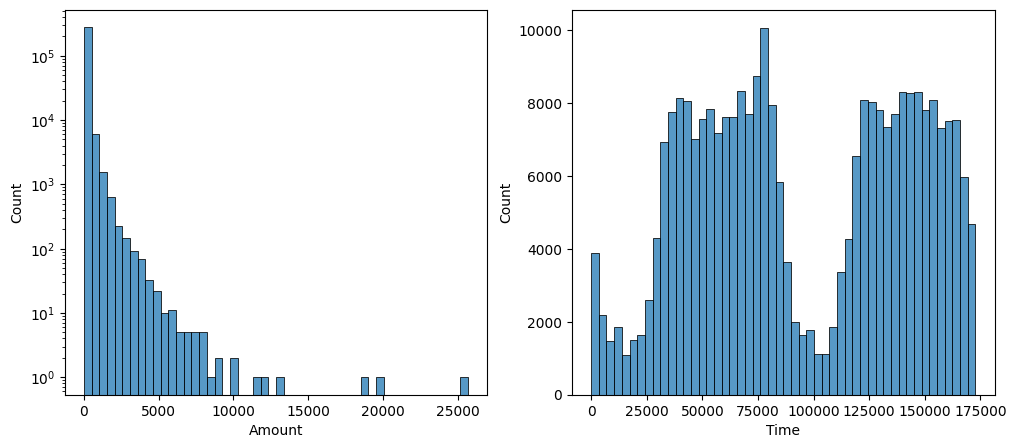

In [17]:
# Amount and time features

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.yscale("log")
sns.histplot(df["Amount"], bins=50)

plt.subplot(1,2,2)
sns.histplot(df["Time"], bins=50)

plt.show()

* "Amount" is skewed, with few large transitions
* "Time" is not uniformely distributed

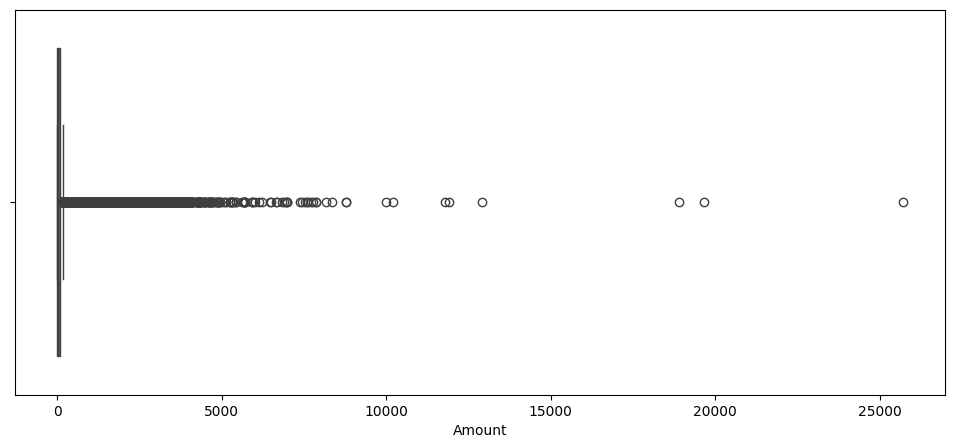

In [18]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df["Amount"])
plt.show()

There are important outliers in the feature "Amount", and they could potentially represent anomalous transactions.

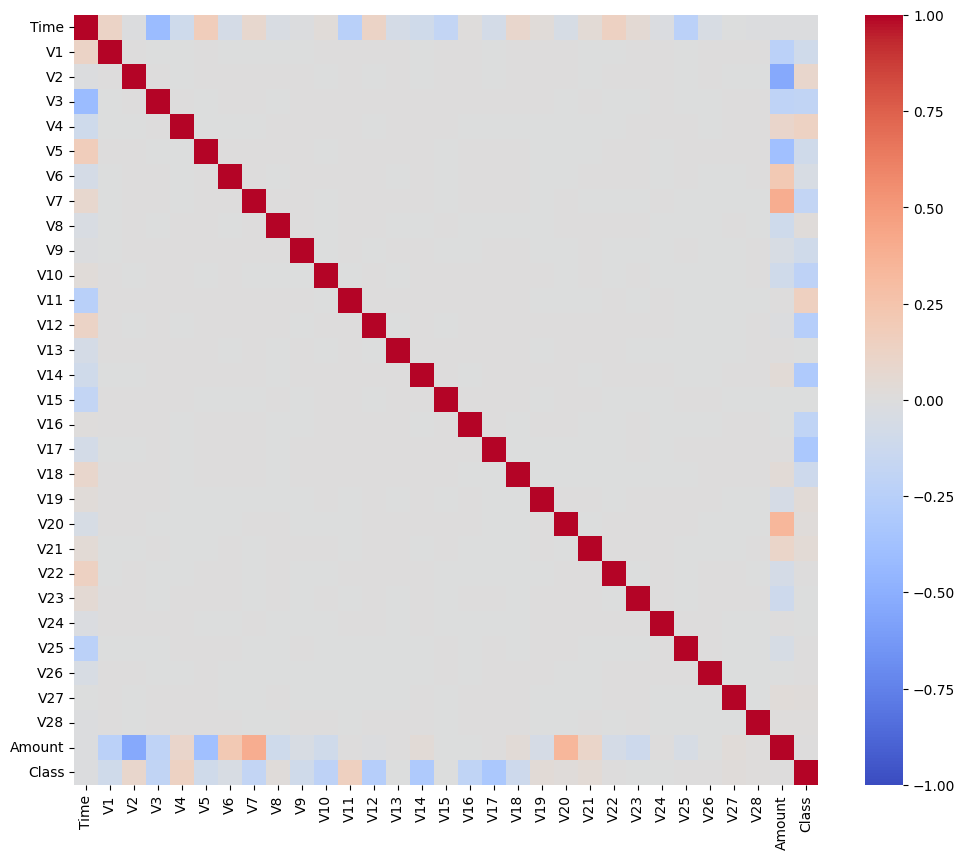

In [20]:
# Correlation matrix

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

Most features aren't correlated, but this is expected because they are PCA transformed.

## 3. Data pre-processing

In [22]:
# Feature scaling -> All the features must contribute equally to the distance calculations

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [23]:
# Check scaling

print(X_scaled.mean(axis=0)[:5])
print(X_scaled.std(axis=0)[:5])

[-3.06563713e-16 -1.50687242e-17 -9.58011603e-18 -8.62210442e-17
 -5.18922951e-18]
[1. 1. 1. 1. 1.]


For visualization, I reduce the dataset to 2 dimensions. This allows already potentially to visualize anomalous points, even if the information isn't complete.

In [28]:
# PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [29]:
pca.explained_variance_ratio_

array([0.06527521, 0.05612313])

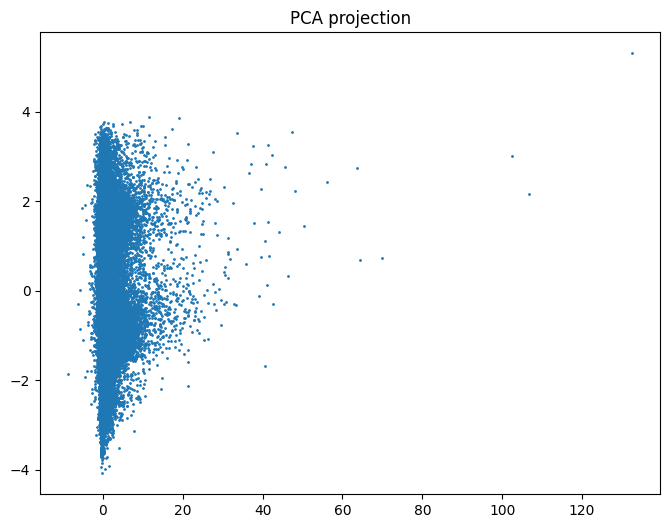

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=1)
plt.title("PCA projection")
plt.show()

There are some points which appear far from the main mass of points -> possible anomalies

## 4. K-Means

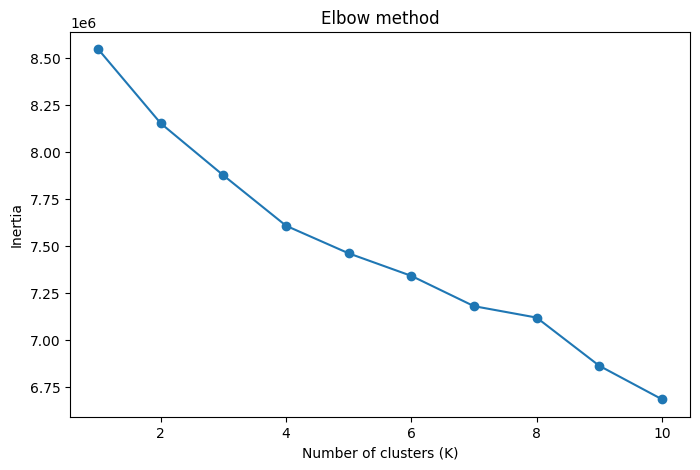

In [32]:
# How many K? -> Elbow method

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

After K=4, the decrease in the inertia becomes more gradual and less steep.

In [33]:
# Train with K=4

k = 4

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

KMeans(n_clusters=4, random_state=42)

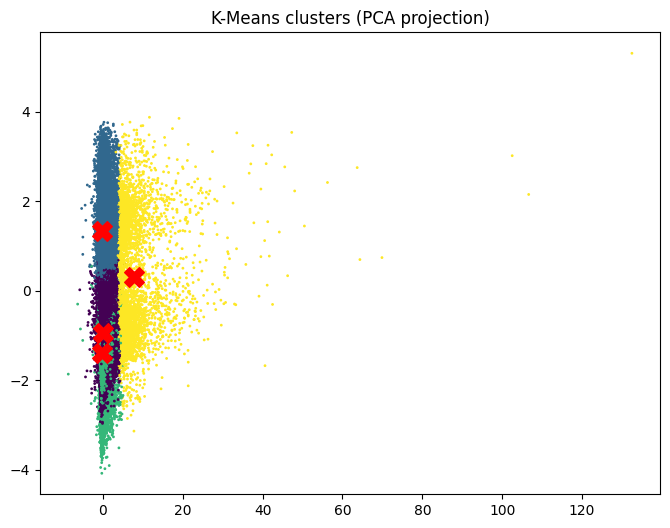

In [37]:
# Cluster assignment and visualization

clusters = kmeans.labels_
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, s=1, cmap="viridis")
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], color="red", s=200, marker="X", label="Centroids")
plt.title("K-Means clusters (PCA projection)")
plt.show()

Some points are far from the centroid of their respective clusters. These ones are potential anomalies.

## 5. Anomaly score

In [40]:
# Calculate distances from centroids

distances = cdist(X_scaled, kmeans.cluster_centers_, metric="euclidean")
dist_to_centroid = distances[np.arange(len(X_scaled)), clusters]

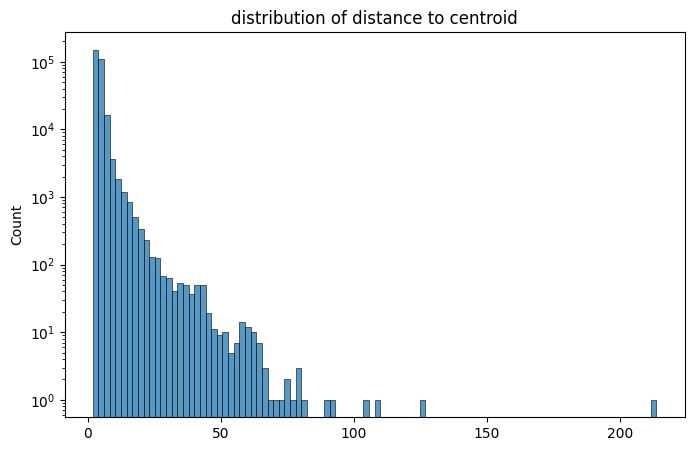

In [42]:
# Distribution od scores

plt.figure(figsize=(8,5))
sns.histplot(dist_to_centroid, bins=100)
plt.title("distribution of distance to centroid")
plt.yscale("log")
plt.show()

Most points have low distance with respect to their centroid, indicating a normal behaviour. 
However, some points have significant higher distance -> These are potential anomalies.

In [43]:
# Definition of a threshold -> 95 percentile

threshold = np.percentile(dist_to_centroid, 95)
anomalies = dist_to_centroid > threshold

In [44]:
# How many anomalies?

np.sum(anomalies)

14241

Anomalies are the 5% of points with largest distance from their cluster centroid.

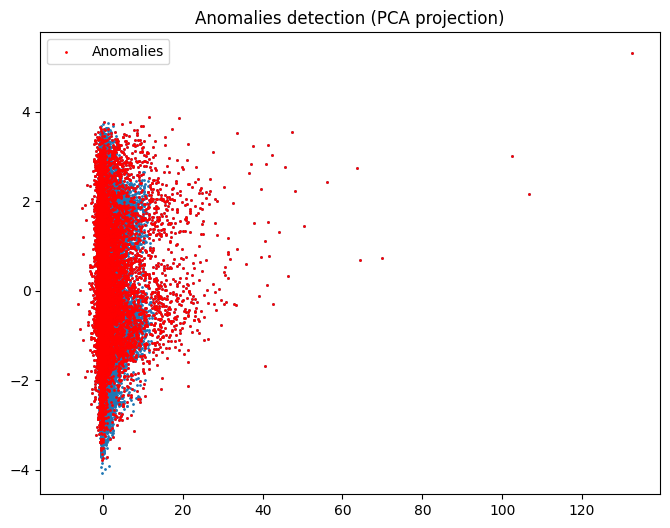

In [49]:
# Visualize anomalies

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], s=1)
plt.scatter(X_pca[anomalies,0], X_pca[anomalies,1], color="red", s=1, label="Anomalies")

plt.title("Anomalies detection (PCA projection)")
plt.legend()
plt.show()

Points far from the dense region are considered as anomalies. Many anomalies lie in the dense region too. This is a consequence of the PCA representation.

In [51]:
# Comparison with real labels

print(classification_report(y, anomalies))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    284315
           1       0.03      0.87      0.06       492

    accuracy                           0.95    284807
   macro avg       0.51      0.91      0.52    284807
weighted avg       1.00      0.95      0.97    284807



Looking at label 1 (fraud), the model detect 87% of real anomalies, but the precision is 3%, meaning that only 3% of the detected anomalies is actually a fraud.

This can be given by the fact that I selected the 5% of the dataset as anomalies. However, missing a fraudolent transaction can be more costly than investigating a legitimate one. The trade-off can be changed anyway, according to the specific need.

## 6. Comparison with Isolation Forest and Local Outlier Factor

* Isolation Forest finds anomalies by randomly partitioning the data
* Local Outlier Factor finds anomalies based on local density

In [53]:
# Isolation Forest

iso = IsolationForest(contamination=0.05, random_state=42)
iso_preds = iso.fit_predict(X_scaled)

iso_anomalies = iso_preds == -1

In [54]:
print(classification_report(y, iso_anomalies))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    284315
           1       0.03      0.85      0.06       492

    accuracy                           0.95    284807
   macro avg       0.51      0.90      0.52    284807
weighted avg       1.00      0.95      0.97    284807



In [55]:
# Local outlier factor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_preds = lof.fit_predict(X_scaled)

lof_anomalies = lof_preds == -1

In [56]:
print(classification_report(y, lof_anomalies))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    284315
           1       0.00      0.12      0.01       492

    accuracy                           0.95    284807
   macro avg       0.50      0.53      0.49    284807
weighted avg       1.00      0.95      0.97    284807



In [57]:
# Comparison

models = {
    "K-Means": anomalies,
    "Isolation Forest": iso_anomalies,
    "LOF": lof_anomalies
}

for name, preds in models.items():
    print(f"\n{name}")
    print(classification_report(y, preds))


K-Means
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    284315
           1       0.03      0.87      0.06       492

    accuracy                           0.95    284807
   macro avg       0.51      0.91      0.52    284807
weighted avg       1.00      0.95      0.97    284807


Isolation Forest
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    284315
           1       0.03      0.85      0.06       492

    accuracy                           0.95    284807
   macro avg       0.51      0.90      0.52    284807
weighted avg       1.00      0.95      0.97    284807


LOF
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    284315
           1       0.00      0.12      0.01       492

    accuracy                           0.95    284807
   macro avg       0.50      0.53      0.49    284807
weighted avg       1.00      0.95      0.9

* Isolation forest has similar performances to K-Means
* LOF isn't able to capture anomalies

In general, the first two models have low precision and high recall. This happens because:
1. The dataset is unbalanced
2. The threshold is fixed